In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
trainpath='/content/drive/MyDrive/Colab Notebooks/Kaggle/Credit Card Fraud Analysis/元データ/train.csv'
testpath='/content/drive/MyDrive/Colab Notebooks/Kaggle/Credit Card Fraud Analysis/元データ/test.csv'
samplepath='/content/drive/MyDrive/Colab Notebooks/Kaggle/Credit Card Fraud Analysis/元データ/sample_submission.csv'

train=pd.read_csv(trainpath)
test=pd.read_csv(testpath)
sample=pd.read_csv(samplepath)
sample

,Idx,Reducted Cost
0,0,1223956.75


GOOGLEｽﾌﾟﾚｯﾄﾞｼｰﾄ（またはエクセル）で概要確認のためCSVの量カット

In [4]:
#0-1　CSVカット
headtail = pd.concat([train.head(1000), train.tail(1000)])
#オフ headtail.to_csv('train_cut.csv',index=False)
print(f"{len(headtail)}行")

2000行


Credit Card Fraud Analysis  
　概要（抜粋）  
　　銀行のモデルを分析し、何が問題なのか、そしてモデルを微調整することで顧客を  
　失わずに済むかどうかを探ってほしいと考えています。なぜなら、顧客を失うことは  
　お金の損失につながるからです。不正行為が発生した場合、損失は不正に発生した金  
　額のみですが、顧客が離れれば、将来の取引と顧客の信頼の両方を失うことになり、  
　その損失はさらに大きくなります。  
  
機能要求     
　　解約リスクや確認コストの観点から指標を４段階評価  
　　・取引停止  
　　・追加認証  
　　・職員によるモニタリング確認  
　　・メール確認  

In [5]:
#0-1　基本確認　df
train.head()

,Idx,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,28925,35238.0,-2.104124,-0.857628,0.295640,0.327326,-1.032066,-0.142956,3.546909,-1.329273,0.442331,0.735090,-0.266014,-1.160803,-1.121976,-0.385897,0.998002,-0.017605,-0.720548,-0.257571,0.148246,-0.627257,-0.558146,0.324999,0.895769,0.416158,-0.006500,0.249827,0.188818,-0.415579,500.0,0
1,145460,86970.0,2.211272,-0.510263,-2.683934,-0.683220,0.548831,-0.890700,0.407377,-0.406795,-1.297024,1.216699,0.213731,-0.075419,-0.699868,0.997132,-0.936908,-1.922281,-0.176043,1.341963,-0.225292,-0.595322,-0.079390,0.267344,-0.122598,0.404999,0.511238,0.989640,-0.139442,-0.097028,28.7,0
2,147284,88327.0,-0.638960,-0.759973,1.389848,-1.366081,1.268624,5.350756,-1.357208,1.570179,0.323975,-0.397500,-1.637814,0.094326,-0.191370,-1.318918,-2.058668,-1.617027,-0.148300,1.525825,-1.681159,-0.477898,-0.145604,0.302993,-0.075193,0.672147,-0.113891,-0.558623,0.277457,0.172700,50.0,0
3,107292,70371.0,1.095059,0.002152,-0.221296,0.466176,0.090094,-0.546550,0.455279,-0.184889,-0.178815,-0.140408,-0.304624,0.259532,0.100726,0.505615,1.048932,-0.149508,-0.100197,-1.196222,-0.142357,0.057657,-0.326294,-1.139242,0.054453,-0.281176,0.229296,0.180543,-0.064573,0.017911,94.9,0
4,57968,48168.0,0.948326,-0.195569,1.274710,1.259601,-1.035730,-0.176373,-0.495985,0.128617,0.148118,0.119336,1.496872,1.154742,0.474505,0.098645,0.672068,0.819640,-0.913244,0.757312,-0.537243,0.091125,0.243013,0.524631,-0.082174,0.540514,0.265511,-0.387708,0.046295,0.048866,94.0,0


In [6]:
#0-2　基本確認　欠損値

# 1. 欠損値の集計
null_sum = train.isnull().sum()

# 2. 条件分岐：欠損があるかないかで表示を変える
if null_sum.sum() == 0:
    # --- 欠損値がゼロの場合 ---
    print("欠損なし")
else:
    # --- 欠損値がある場合（既存の処理） ---
    null_ratio = 100 * null_sum / len(train)
    null_table = pd.concat([null_sum, null_ratio], axis=1)
    null_table_renamed = null_table.rename(
        columns={0: '欠損数', 1: '欠損率(%)'}
    ).sort_values(by='欠損率(%)', ascending=False)

    # 欠損がある行だけを表示
    print("欠損")
    print(null_table_renamed[null_table_renamed['欠損数'] > 0])

欠損なし


In [7]:
#0-3　基本確認　均衡確認（不正件数、全体件数、不正件数割合）

# 1. 基本件数の集計
total_count = len(train)
fraud_df = train[train['Class'] == 1]
normal_df = train[train['Class'] == 0]

fraud_count = len(fraud_df)
normal_count = len(normal_df)
fraud_ratio = (fraud_count / total_count) * 100

# 2. 金額（Amount）の集計
total_amount = train['Amount'].sum()
fraud_amount = fraud_df['Amount'].sum()
amount_ratio = (fraud_amount / total_amount) * 100

# 4. レポート表示
print(f"--- 【均衡確認】 ---")
print(f"全体件数: {total_count:,} 件")
print(f"正常件数: {normal_count:,} 件")
print(f"不正件数: {fraud_count:,} 件 (本来の{fraud_count}件)")
print(f"不正件数割合: {fraud_ratio:.4f} %")
print("-" * 35)
print(f"全体取引総額: ${total_amount:,.2f}")
print(f"不正被害総額: ${fraud_amount:,.2f}")
print(f"不正金額割合: {amount_ratio:.4f} %")
print(f"1件あたりの平均不正額: ${fraud_df['Amount'].mean():,.2f}")
print(f"不正の最大金額: ${fraud_df['Amount'].max():,.2f}")
print(f"不正金額の標準偏差 (std): ${fraud_df['Amount'].std():,.2f}")


--- 【均衡確認】 ---
全体件数: 199,364 件
正常件数: 199,004 件
不正件数: 360 件 (本来の360件)
不正件数割合: 0.1806 %
-----------------------------------
全体取引総額: $17,561,654.53
不正被害総額: $47,609.26
不正金額割合: 0.2711 %
1件あたりの平均不正額: $132.25
不正の最大金額: $2,125.87
不正金額の標準偏差 (std): $281.62


不正件数割合: 0.1806 %の不均衡モデルであるため、不正値について慎重に検討を実施。

In [8]:
#1-1　目的変数の確認　不正の最頻値

fraud_data = train[train['Class'] == 1]['Amount'].value_counts().reset_index()
fraud_data.columns = ['Amount', 'Frequency']

amt_desc = fraud_data.sort_values(by='Amount', ascending=False).head(30).reset_index(drop=True)
freq_desc = fraud_data.sort_values(by='Frequency', ascending=False).head(30).reset_index(drop=True)

comparison_df = pd.concat([amt_desc, freq_desc], axis=1)
comparison_df.columns = ['Amount', 'Freq', 'Amount', 'Freq']

# 列の間隔を広げて表示
# col_spaceで各列の最小幅を指定します
print("　　　【金額降順】 　　　　 【頻度降順】")
print("-" * 50)
print(comparison_df.to_string(index=False, justify='right', col_space=10))

# --- 追加：100ドル未満の不正シェア算出 ---
total_fraud_count = (train['Class'] == 1).sum()
under_100_fraud_count = ((train['Class'] == 1) & (train['Amount'] < 100)).sum()
under_100_ratio = (under_100_fraud_count / total_fraud_count) * 100

print("-" * 50)
print(f"【不正取引のボリュームゾーン分析】")
print(f"全不正件数: {total_fraud_count} 件")
print(f"＄100以下の不正件数: {under_100_fraud_count} 件")
print(f"＄100以下の不正割合: {under_100_ratio:.2f} %")

　　　【金額降順】 　　　　 【頻度降順】
--------------------------------------------------
    Amount       Freq     Amount       Freq
   2125.87          1       1.00         84
   1809.68          1      99.99         22
   1504.93          1       0.00         21
   1402.16          1       0.76         11
   1389.56          1       0.77          6
   1354.25          1       3.79          4
   1335.00          1       0.01          4
   1218.89          1       0.68          3
    996.27          1       2.28          3
    925.31          1      19.02          2
    829.41          1       8.00          2
    824.83          1      18.96          2
    802.52          1     104.03          2
    776.83          1       0.83          2
    766.36          1      88.23          2
    730.86          1      45.51          2
    727.91          1      39.45          2
    723.21          1       1.10          2
    720.80          1     101.50          2
    720.38          1     111.70          2
   

100ドル未満の割合が7割超であるためそのまま分析を行うと低価格帯が不正だと学習してしまうリスクあり。

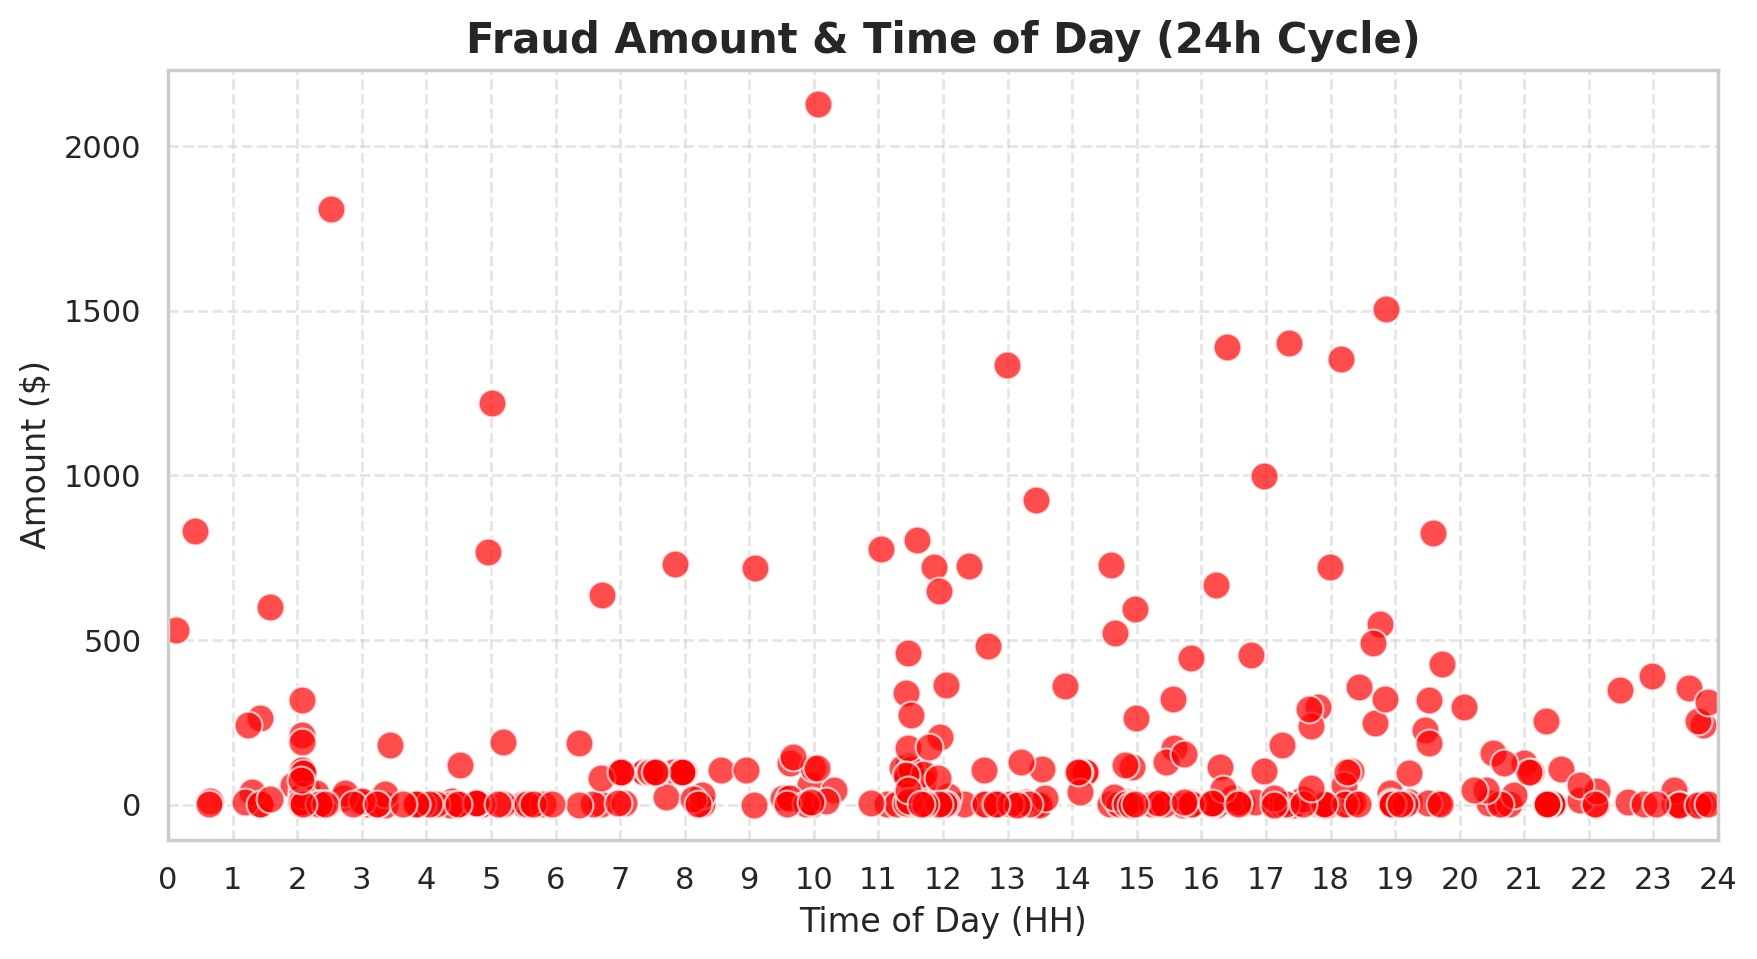

In [15]:
#1-2　目的変数の確認　不正散布図（時間軸）

import matplotlib.ticker as ticker

# 1. 不正データのみ抽出
fraud_only = train[train['Class'] == 1].copy()

# 2. 経過秒数を「1日の中の秒数（0〜86399）」に変換
# 86400秒（24時間）で割った余りを使うことで、2日間のデータを24時間に集約
fraud_only['time_of_day'] = fraud_only['Time'] % 86400

# 3. 描画
plt.figure(figsize=(10, 5))

# X軸に変換後の「time_of_day」を指定
sns.scatterplot(data=fraud_only, x='time_of_day', y='Amount',
                color='red', s=100, alpha=0.7, edgecolor='white')

# 💡 X軸の数値を時刻（HH:MM）に変換する関数
@ticker.FuncFormatter
def time_formatter(x, pos):
    h = int(x // 3600)
    m = int((x % 3600) // 60)
    return f"{h}"


plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(3600 * 1))
plt.gca().xaxis.set_major_formatter(time_formatter)

plt.xlim(0, 86400) # 0時から24時まで
plt.title("Fraud Amount & Time of Day (24h Cycle)", fontsize=15, fontweight='bold')
plt.xlabel("Time of Day (HH)", fontsize=12)
plt.ylabel("Amount ($)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

１００～５００ドル間は時間との相関あり  
*   2時頃
*   11～12時前後
*   14時～24時はまばら

以下、取引金額を100未満、100以上500未満、500以上に分類し  
相関のある特徴量を確認

In [10]:
#1-3　目的変数の確認　他特徴量の単体相関(金額1)

results = []
v_cols = [f'V{i}' for i in range(1, 29)]

for amt in [500, 1000, 1500]:
    # 指定金額以上のデータを抽出
    subset = train[train['Amount'] >= amt].copy()
    fraud = subset[subset['Class'] == 1]
    normal = subset[subset['Class'] == 0]

    # 件数チェック（ここが 0 だと NaN になるので重要）
    f_count = len(fraud)
    n_count = len(normal)
    print(f"${amt}以上: 不正 {f_count}件 / 正常 {n_count}件")

    # 相関の計算
    # 不正グループでの V1-28 と Amount の相関
    if f_count > 1:
        f_corr = fraud[v_cols + ['Amount']].corr()['Amount'].drop('Amount')
    else:
        f_corr = pd.Series(0, index=v_cols) # 件数不足なら0埋め

    # 正常グループでの V1-28 と Amount の相関
    if n_count > 1:
        n_corr = normal[v_cols + ['Amount']].corr()['Amount'].drop('Amount')
    else:
        n_corr = pd.Series(0, index=v_cols)

    # 結果をまとめる
    for v in v_cols:
        results.append({
            'Amount_Limit': amt,
            'V_Col': v,
            'Fraud_Corr': f_corr[v],
            'Normal_Corr': n_corr[v],
            'Diff': abs(f_corr[v] - n_corr[v])
        })

# 表示用のデータフレーム作成
df_res = pd.DataFrame(results)

for amt in [500, 1000, 1500]:
    print(f"\n === Amount ${amt} 以上：Amountとの相関比較 (Diff順位) ===")
    display_df = df_res[df_res['Amount_Limit'] == amt].sort_values('Diff', ascending=False)
    print(display_df[['V_Col', 'Fraud_Corr', 'Normal_Corr', 'Diff']].head(10).to_string(index=False, col_space=10))

final_comparison = df_res.pivot(index='V_Col', columns='Amount_Limit')

$500以上: 不正 29件 / 正常 6620件
$1000以上: 不正 8件 / 正常 2125件
$1500以上: 不正 3件 / 正常 940件

 === Amount $500 以上：Amountとの相関比較 (Diff順位) ===
     V_Col  Fraud_Corr  Normal_Corr       Diff
        V7    0.045806     0.683804   0.637998
        V5   -0.206159    -0.630600   0.424441
        V6    0.100459     0.495861   0.395402
        V3   -0.216855    -0.605916   0.389061
        V1   -0.110902    -0.456807   0.345905
       V10   -0.037116    -0.361353   0.324236
       V15   -0.143853     0.160718   0.304571
        V2   -0.319054    -0.592477   0.273423
       V16    0.011349     0.229008   0.217659
       V13   -0.094141     0.119937   0.214078

 === Amount $1000 以上：Amountとの相関比較 (Diff順位) ===
     V_Col  Fraud_Corr  Normal_Corr       Diff
       V10    0.690846    -0.460802   1.151648
        V3    0.398225    -0.665251   1.063476
        V4   -0.564169     0.451869   1.016038
        V1    0.400358    -0.513671   0.914029
        V9    0.793206    -0.097208   0.890414
       V14    0.877663     0.

高金額帯は強い相関がみられるが、件数が少なすぎるため学習困難。  
頻出度と時間帯別の散布図より取引金額100，500で区切った相関を確認。

In [11]:
#1-3　目的変数の確認　他特徴量の単体相関(金額2)

results = []
v_cols = [f'V{i}' for i in range(1, 29)]

# 新しいセグメント定義
segments = [
    ('$100以上', train[train['Amount'] < 100]),
    ('$100 - $500', train[(train['Amount'] >= 100) & (train['Amount'] < 500)]),
    ('$500以上',  train[train['Amount'] >= 500])
]

s_fraud = subset[subset['Class'] == 1]
s_normal = subset[subset['Class'] == 0]

# ヘッダー表示
print(f"{'Segment':<15} | {'Fraud / Normal':<22} | {'Fraud Ratio'}")
print("-" * 55)

for label, subset in segments:
    s_fraud = subset[subset['Class'] == 1]
    s_normal = subset[subset['Class'] == 0]
    f_count = len(s_fraud)
    n_count = len(s_normal)

    # 割合の計算
    ratio = (f_count / (f_count + n_count) * 100) if (f_count + n_count) > 0 else 0
    print(f"{label:<10}: 不正 {f_count:>3}件 / 正常 {n_count:>6}件  |  {ratio:.3f} %")


    # 不正グループの相関
    if f_count > 1:
        f_corr = s_fraud[v_cols + ['Amount']].corr()['Amount'].drop('Amount')
    else:
        f_corr = pd.Series(0, index=v_cols)

    # 正常グループの相関
    if n_count > 1:
        n_corr = s_normal[v_cols + ['Amount']].corr()['Amount'].drop('Amount')
    else:
        n_corr = pd.Series(0, index=v_cols)

    # 結果をリストに格納
    for v in v_cols:
        results.append({
            'Segment': label,
            'V_Col': v,
            'Fraud_Corr': f_corr[v],
            'Normal_Corr': n_corr[v],
            'Diff': abs(f_corr[v] - n_corr[v])
        })

# 表示用データフレーム
df_res = pd.DataFrame(results)

# 各セグメントのTOP10を表示
for label, _ in segments:
    print(f"\n=== {label}：Amountとの相関比較 (Diff順位) ===")
    display_df = df_res[df_res['Segment'] == label].sort_values('Diff', ascending=False)
    # フォーマットを整えて出力
    print(display_df[['V_Col', 'Fraud_Corr', 'Normal_Corr', 'Diff']].head(10).to_string(index=False, justify='right', col_space=10))

Segment         | Fraud / Normal         | Fraud Ratio
-------------------------------------------------------
$100以上    : 不正 263件 / 正常 158943件  |  0.165 %
$100 - $500: 不正  68件 / 正常  33441件  |  0.203 %
$500以上    : 不正  29件 / 正常   6620件  |  0.436 %

=== $100以上：Amountとの相関比較 (Diff順位) ===
     V_Col  Fraud_Corr  Normal_Corr       Diff
        V2    0.359170    -0.239721   0.598891
        V1   -0.464422     0.017894   0.482316
        V3   -0.420241     0.037552   0.457793
        V8    0.456437     0.030704   0.425732
        V6   -0.347007     0.078178   0.425185
        V5   -0.524118    -0.140838   0.383281
       V18   -0.308323     0.031305   0.339628
       V17   -0.303763     0.013788   0.317552
       V25    0.314588     0.015082   0.299506
       V24    0.263254    -0.012239   0.275493

=== $100 - $500：Amountとの相関比較 (Diff順位) ===
     V_Col  Fraud_Corr  Normal_Corr       Diff
       V25    0.361682    -0.016209   0.377890
       V27    0.312338    -0.011151   0.323489
        V3    


*   高金額帯になるほど不正率は高い
*   低金額帯と高金額帯では取引金額とVの相関が取れたものの中金額帯では相関みられず

In [12]:
#1-4　目的変数の確認　他特徴量の単体相関(時間)

results_time_all = []
v_cols = [f'V{i}' for i in range(1, 29)]

for label, subset in segments:
    # Timeを20分スロット(0-71)に変換
    temp_subset = subset.copy()
    temp_subset['Time_Slot'] = (temp_subset['Time'] // 1200) % 72

    fraud = temp_subset[temp_subset['Class'] == 1]
    normal = temp_subset[temp_subset['Class'] == 0]

    # Time_Slotとの相関
    f_corr = fraud[v_cols + ['Time_Slot']].corr()['Time_Slot'].drop('Time_Slot') if f_count > 1 else pd.Series(0, index=v_cols)
    n_corr = normal[v_cols + ['Time_Slot']].corr()['Time_Slot'].drop('Time_Slot') if n_count > 1 else pd.Series(0, index=v_cols)

    for v in v_cols:
        results_time_all.append({
            'Segment': label,
            'V_Col': v,
            'Fraud_Corr_Time': f_corr[v],
            'Normal_Corr_Time': n_corr[v],
            'Diff_Time': abs(f_corr[v] - n_corr[v])
        })

df_time_res = pd.DataFrame(results_time_all)

# 各セグメントのTOP10を表示
for label, _ in segments:
    print(f"\n === {label}：時間(20分刻み)との相関比較 (Diff順位) ===")
    display_df = df_time_res[df_time_res['Segment'] == label].sort_values('Diff_Time', ascending=False)
    print(display_df[['V_Col', 'Fraud_Corr_Time', 'Normal_Corr_Time', 'Diff_Time']].head(10).to_string(index=False, justify='right', col_space=12))


 === $100以上：時間(20分刻み)との相関比較 (Diff順位) ===
       V_Col  Fraud_Corr_Time  Normal_Corr_Time    Diff_Time
          V9         0.262197         -0.201230     0.463427
          V3         0.396553         -0.029357     0.425910
         V10         0.427622          0.012585     0.415037
         V17         0.327707         -0.086349     0.414056
          V5         0.352895         -0.051266     0.404161
          V2        -0.381267          0.015755     0.397022
          V7         0.373566         -0.022961     0.396527
          V4        -0.419596         -0.033593     0.386002
         V14         0.162855         -0.192245     0.355100
         V16         0.360969          0.006956     0.354013

 === $100 - $500：時間(20分刻み)との相関比較 (Diff順位) ===
       V_Col  Fraud_Corr_Time  Normal_Corr_Time    Diff_Time
         V14         0.414160         -0.132897     0.547057
          V2        -0.542257         -0.003238     0.539020
          V3         0.436978         -0.039854     0.476

一方で中価格帯においては時間(20分刻み)との相関がみられた

下処理検討

1. Vカラム以外の処理検討（Time)  
   Timeは0時から秒でカウント,max47.99であることから  
   2日分の記録である。  
   (1)時間変換（24時間を超える場合は24時間を減算)   
   (2)20分区切り、20分未満の時間を切捨て  

2. Vカラム以外の処理検討(Amount)  
  前述のとおり、V1～V28との相関が金額帯・時間帯で変わるためビン分けを実施。  
分け方は3分類（①100未満②100以上～500未満③500以上）

3. Vカラム以外の処理検討(Idx)  
   重複番号がなければ取引ごとのId番号であるため不要  

4. Vカラムの処理  
   カットデータの統計情報(GOOGLEスプレッドシート使用)より、  
   標準化されており処理不要と思料される。



In [13]:
#2-1　下処理検討　Vカラム以外の処理検討（Idx)

idx_counts = train.groupby('Idx').size()
duplicates = idx_counts[idx_counts > 1]

if len(duplicates) > 0:
    print(f"重複Idx {len(duplicates)} 件")
    print(duplicates)
else:
    print("重複なし")


重複なし


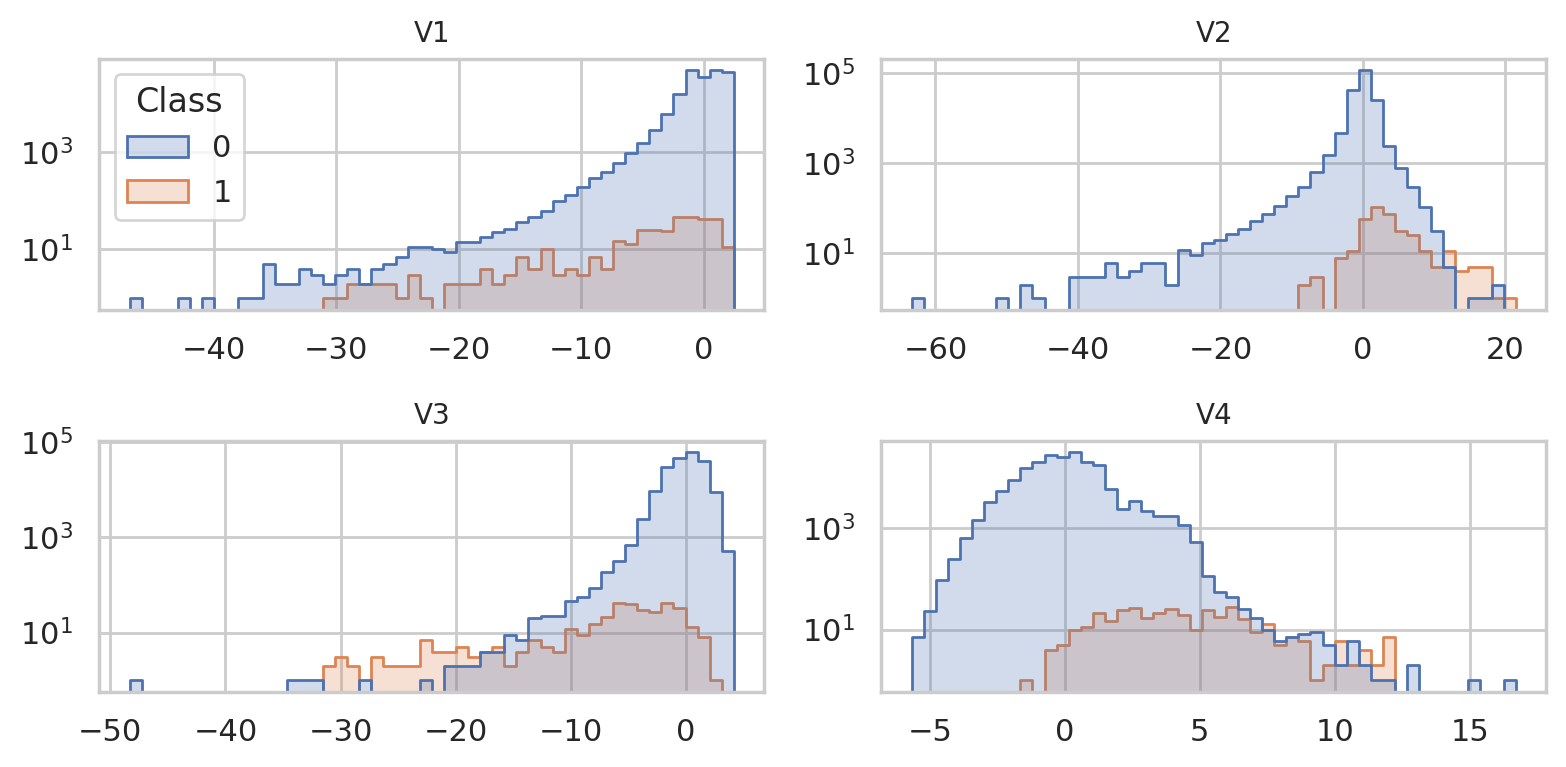

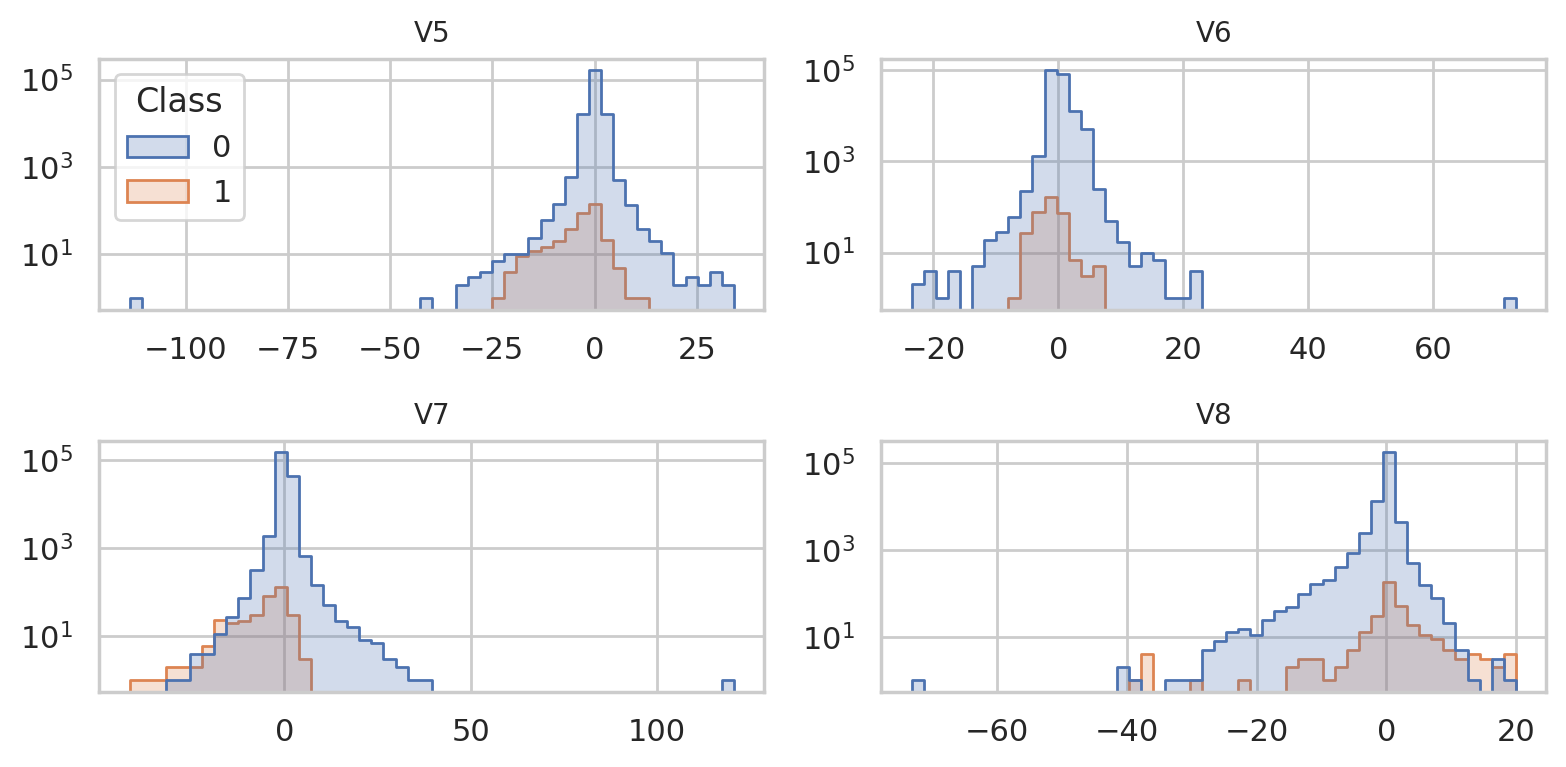

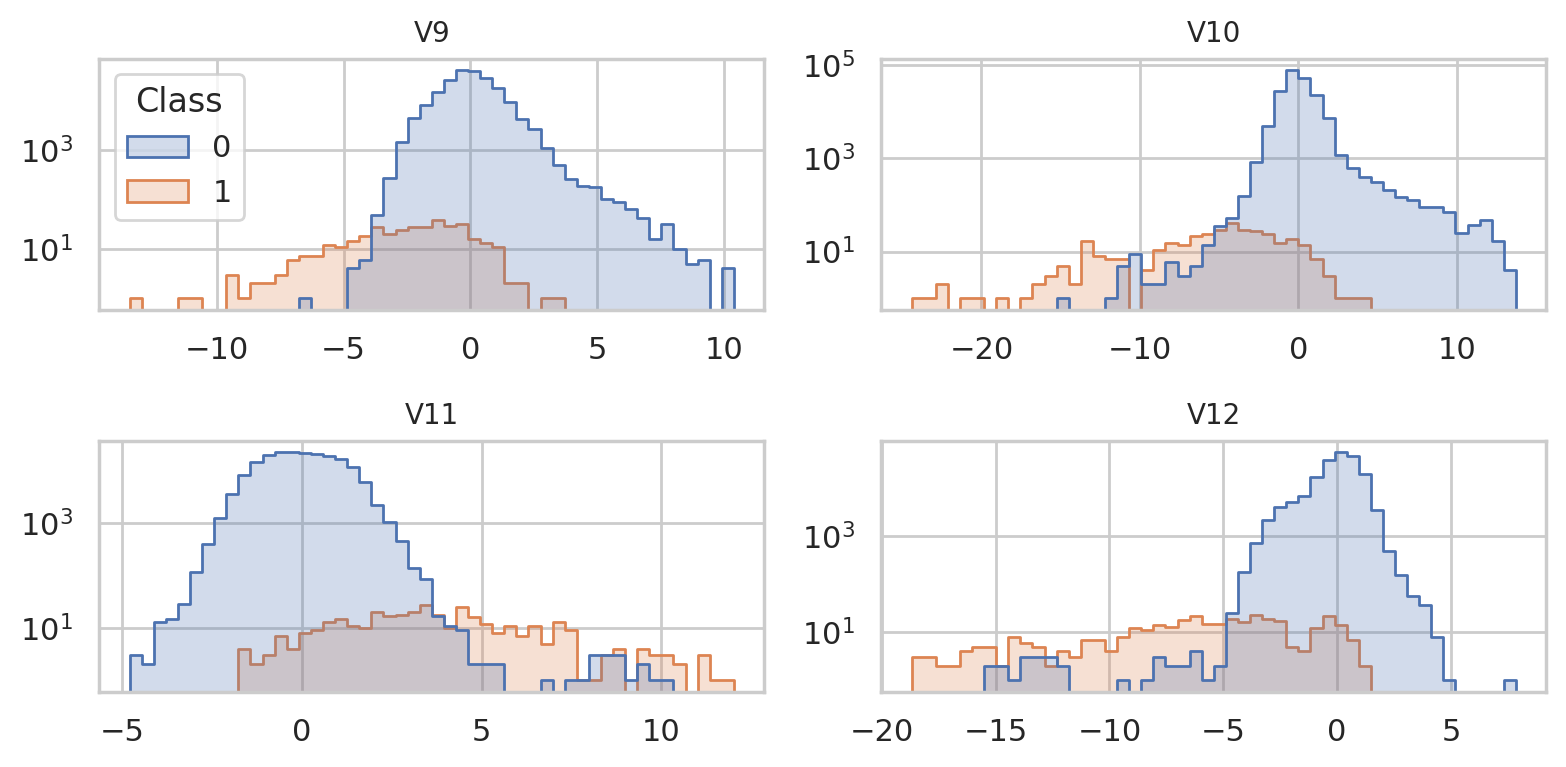

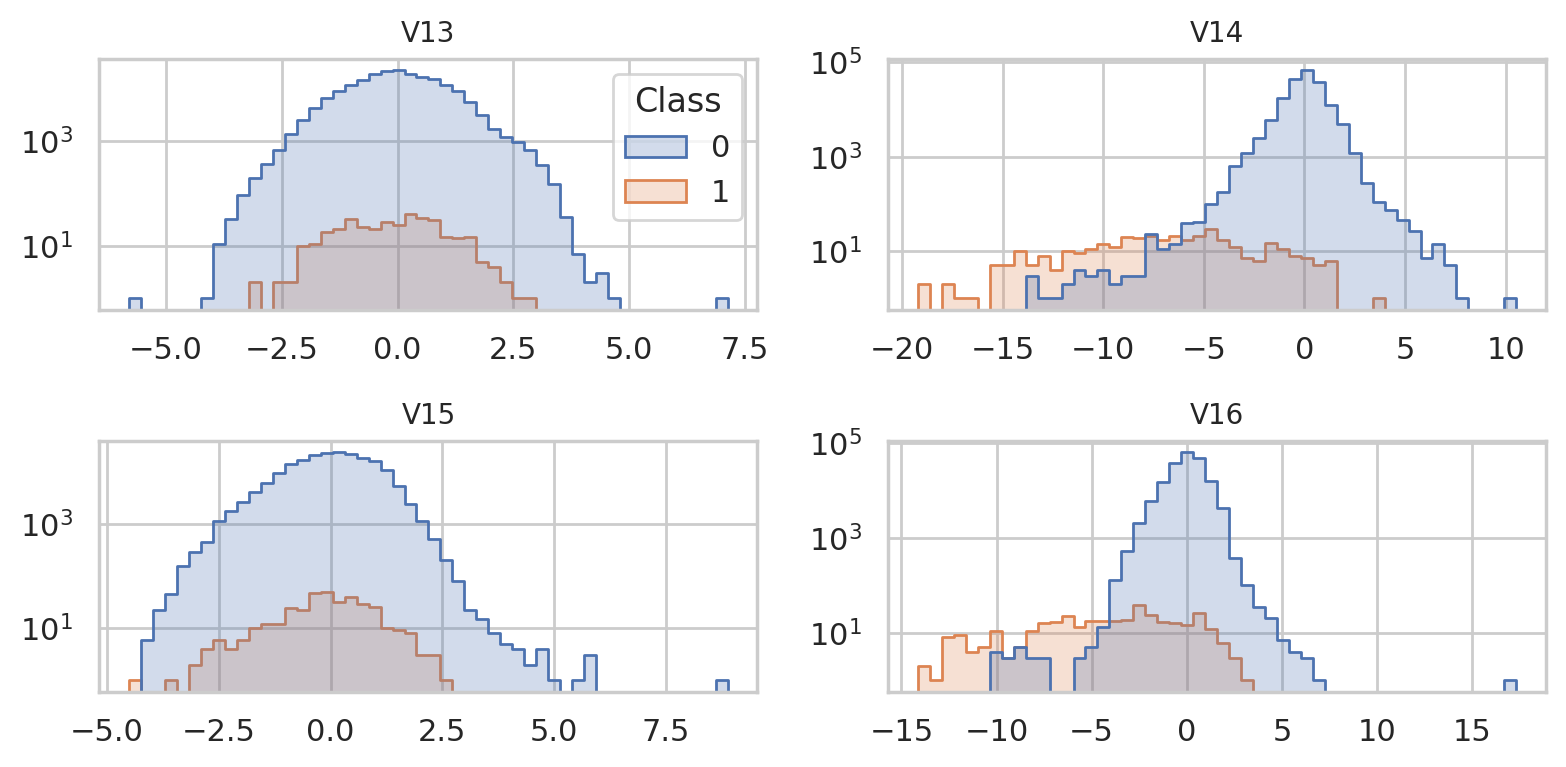

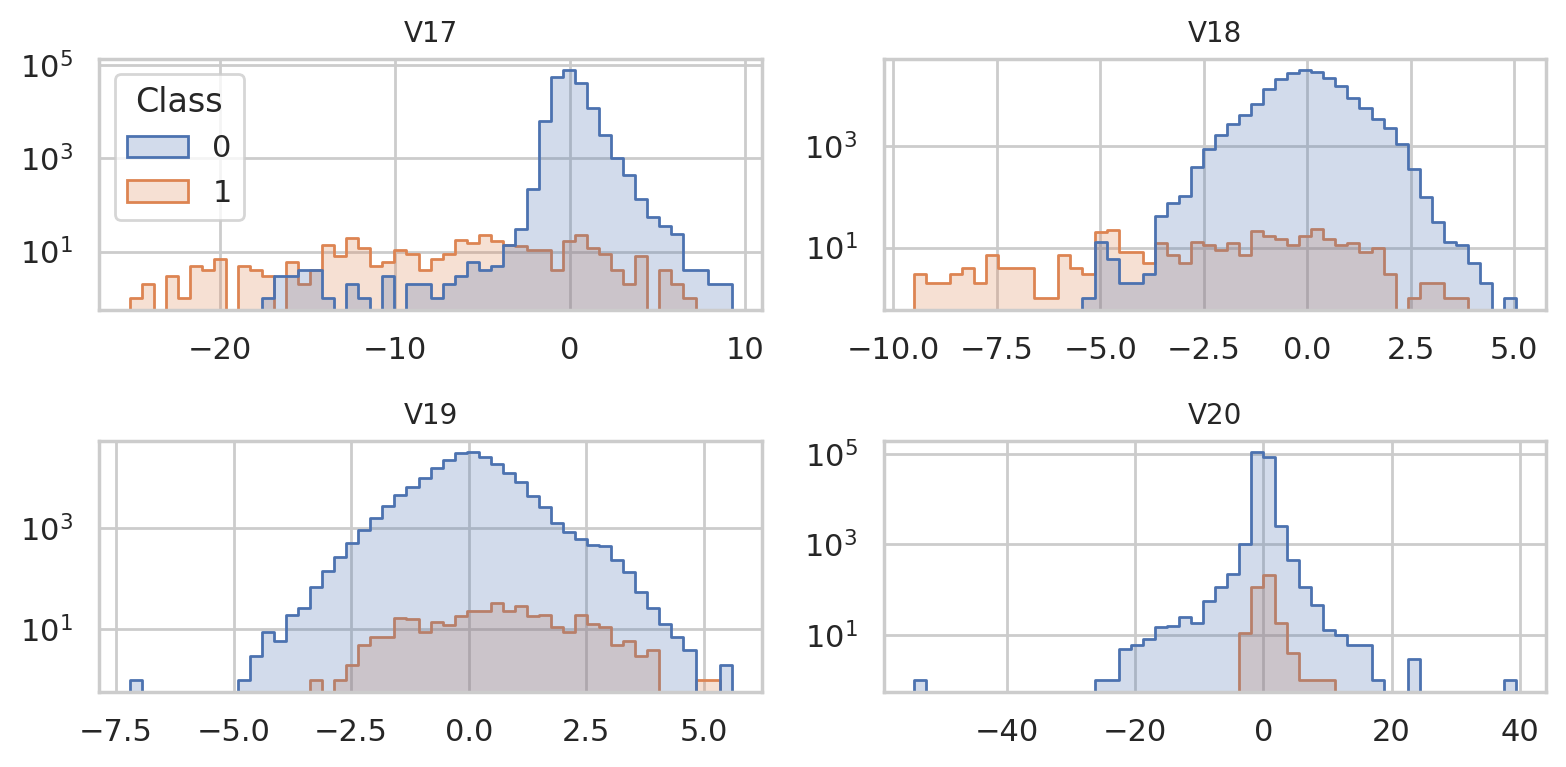

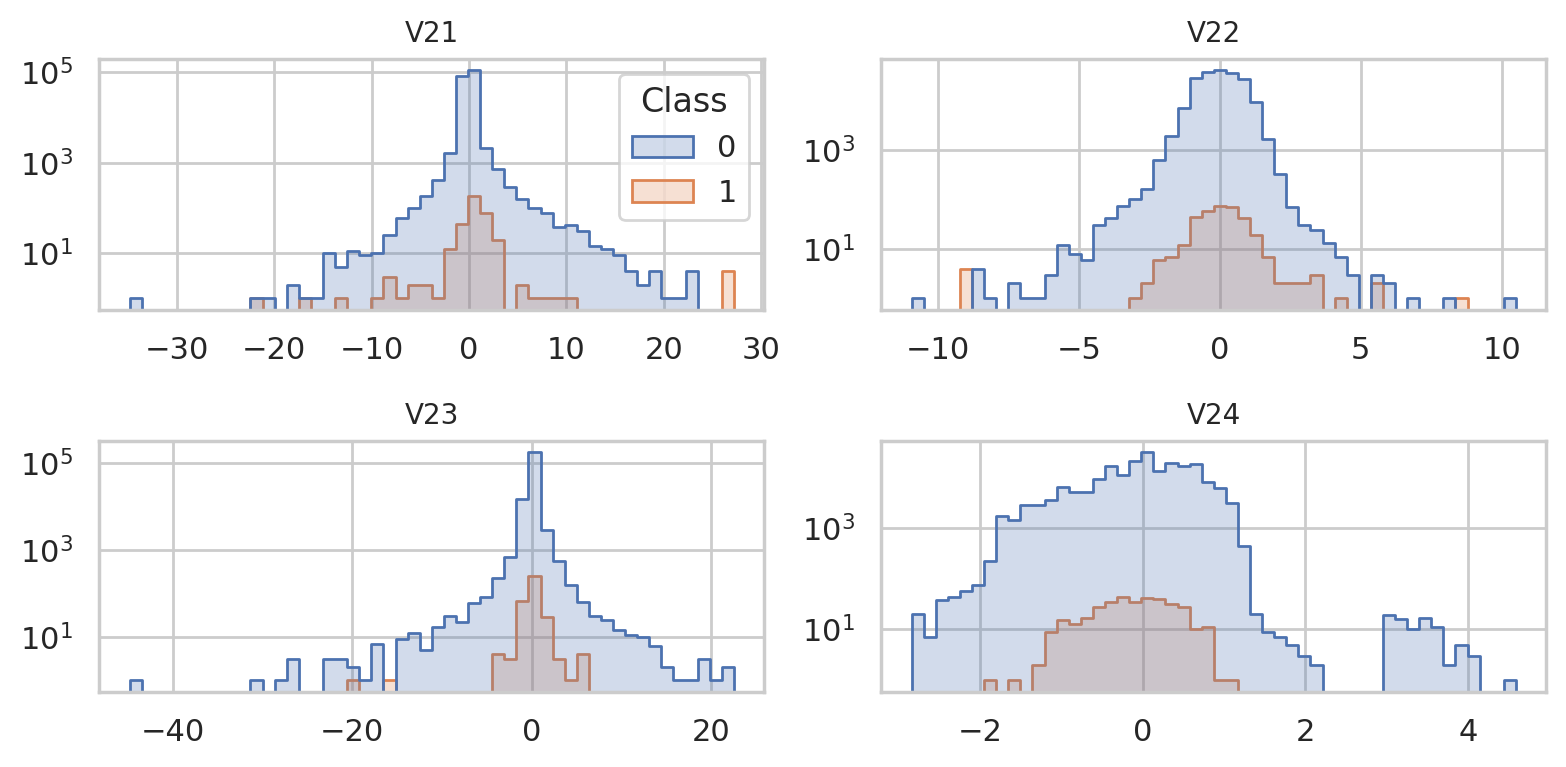

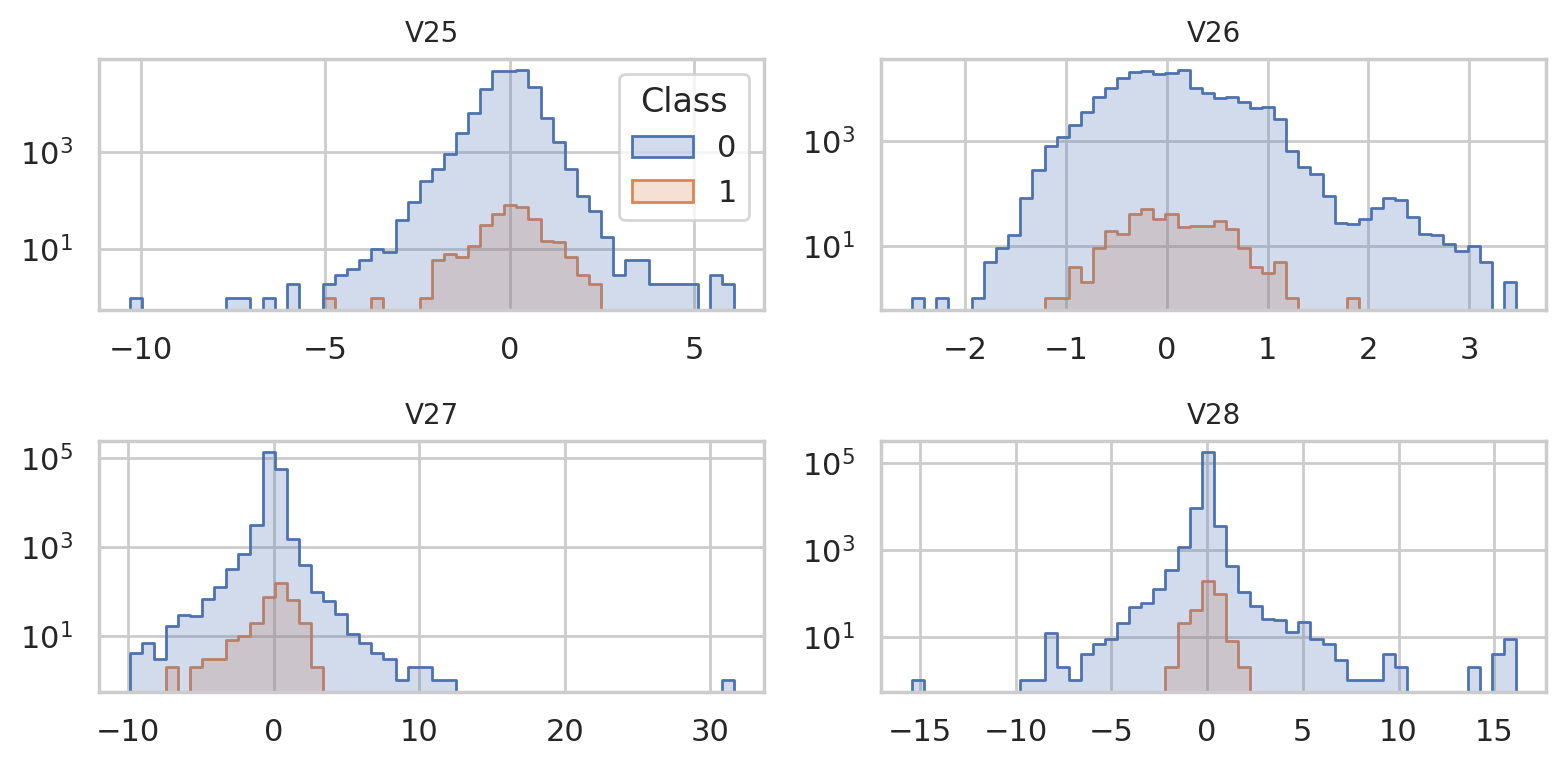

In [14]:
#2-2　下処理検討　Vカラムの処理

#グラフ可視化
v_features = [f'V{i}' for i in range(1, 29)]

for i in range(0, 28, 4):
    v_subset = v_features[i:i+4]
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 4))
    axes = axes.flatten()

    for j, col in enumerate(v_subset):
        sns.histplot(data=train, x=col, hue='Class', bins=50,
                     element="step", ax=axes[j], legend=(j==0))
        axes[j].set_yscale('log')
        axes[j].set_title(f'{col}', fontsize=10)
        axes[j].set_xlabel('')
        axes[j].set_ylabel('')

    plt.tight_layout()
    plt.show()

V値はすでに標準化されてるため予定通り処理不要。

下処理　検討後

1. Vカラム以外の処理検討（Time)  
   (1)時間変換（24時間を超える場合は24時間を減算)   
   (2)20分区切り、20分未満の時間を切捨て  

2. Vカラム以外の処理検討(Amount)  
  前述のとおり、V1～V28との相関が金額帯・時間帯で変わるためビン分けを実施。  
分け方は3分類（①100未満②100以上～500未満③500以上）

3. Vカラム以外の処理検討(Idx)  
   重複ないため処理不要

4. Vカラムの処理  
   対数スケール（y軸)ヒストグラムより、標準化されており処理不要

